# 07 Task 2B: peak-day fleet allocation

**Purpose:** plan scenario S1, a peak day at Peliyagoda just before a festival with ten vehicles in the workshop. Every order is either served on a named vehicle and trip, or deferred with a reason.

**Approach in one paragraph.** The plan is found by an optimiser, not by hand. It follows Waypoint's operating rules exactly and chooses between valid plans by a fixed order of priorities, agreed with the business before any numbers were run. Each priority is solved to its best value and locked in before the next one is looked at, so nothing lower down can buy itself a better score by giving up something more important. We then prove which deferrals were forced and which were choices, put a price on each choice, replay the plan on the clock against store windows, and test what each workshop repair would be worth.

**Inputs:** the S1 orders and fleet status, `vehicles.csv`, `district_travel.csv`, `service_allowance.csv`, and the route history from notebook 03 for the clock check.

**Outputs:**
- `submissions/submission_task2b.csv`, checked with Waypoint's allocation checker
- `data/processed/task2b_plan.parquet` and `task2b_timeline.parquet` for notebook 08
- the numbers behind the one-page policy in `docs/task2b_policy.md`

In [1]:
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xora import allocation as al
from xora.io import load_processed, load_raw, save_processed
from xora.paths import REPO_ROOT, SUBMISSIONS
from xora.plotting import apply_style, SERIES, INK, INK_SOFT

apply_style()
pd.set_option("display.width", 160)

scenarios = load_raw("task2b_peak_day_scenarios.csv")
fleet = load_raw("task2b_peak_day_fleet.csv")
vehicles = load_raw("vehicles.csv")
travel = load_raw("district_travel.csv")
allowance = load_raw("service_allowance.csv")

prob = al.load_problem(scenarios, fleet, vehicles, travel, allowance, scenario="S1")
orders, avail = prob.orders.reset_index(drop=True), prob.vehicles.reset_index(drop=True)
print(f"{len(orders)} orders, {orders.order_volume_m3.sum():.1f} m3, all for {orders.depot.unique()[0]}")
print(f"{len(avail)} vehicles available, {(fleet.status != 'available').sum()} in the workshop")

85 orders, 409.9 m3, all for Peliyagoda
28 vehicles available, 10 in the workshop


## 1. The day at a glance

The question is not whether the fleet has enough space overall. It is whether it has the right kind of space in the right place: chilled goods can only ride on a reefer, a trip can only serve one brand in one district, and the pre-dawn Fresh window is only 270 minutes long.

In [2]:
v = avail.assign(kind=np.where(avail.temp == "reefer", "reefer", "ambient") + " " + avail.type)
fleet_view = v.groupby("kind").agg(vehicles=("vehicle_id", "size"), m3_per_trip=("volume_cap_m3", "sum"))
workshop = fleet[fleet.status != "available"].merge(vehicles, on="vehicle_id")
fleet_view["in_workshop"] = workshop.assign(kind=np.where(workshop.temp == "reefer", "reefer", "ambient") + " " + workshop.type
                                            ).groupby("kind").size().reindex(fleet_view.index).fillna(0).astype(int)

demand = orders.assign(kind=orders.brand + " " + orders.temp_requirement).groupby("kind").agg(
    orders=("order_ref", "size"), m3=("order_volume_m3", "sum"), kg=("order_weight_kg", "sum"))
display(fleet_view.round(1), demand.round(1))

,vehicles,m3_per_trip,in_workshop
kind,,,
ambient truck,22,656.0,5
ambient van,2,17.0,0
reefer truck,3,79.2,4
reefer van,1,7.0,1


,orders,m3,kg
kind,,,
Fresh ambient,49,133.0,24838.4
Fresh chilled,26,181.6,32780.4
Style ambient,5,77.2,4878.3
Tech ambient,5,18.1,5642.3


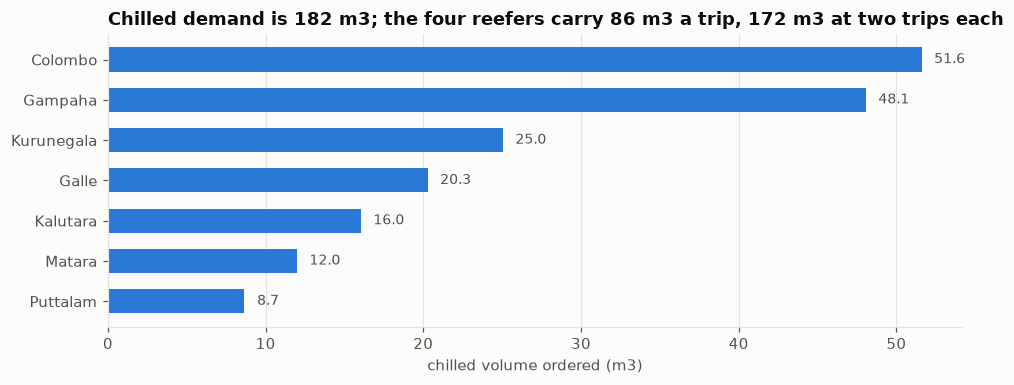

In [3]:
reefer_cap = avail.loc[avail.temp == "reefer", "volume_cap_m3"].sum()
chilled = orders[orders.temp_requirement == "chilled"]
by_district = chilled.groupby("district").order_volume_m3.sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.barh(by_district.index, by_district.values, color=SERIES[0], height=0.6)
for y, val in enumerate(by_district.values):
    ax.text(val + 0.8, y, f"{val:.1f}", va="center", color=INK_SOFT, fontsize=9)
ax.set_xlabel("chilled volume ordered (m3)")
ax.set_title(f"Chilled demand is {chilled.order_volume_m3.sum():.0f} m3; the four reefers carry {reefer_cap:.0f} m3 a trip, {2 * reefer_cap:.0f} m3 at two trips each")
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

Two facts set up the whole day:
- **Ambient space is plentiful.** 22 ambient trucks and two ambient vans are free, far more than the ambient orders need.
- **Chilled space is not.** Four of the seven reefer trucks and the second reefer van are in the workshop. Even if every remaining reefer ran two full trips, it could not carry all the chilled orders, and far districts like Galle, Matara and Puttalam take most of a reefer's 270 pre-dawn minutes on their own.

So the real decisions of the day are about the reefers.

## 2. Deferrals that no plan can avoid

Before optimising anything, we check which orders cannot be served by any vehicle at all, whatever else happens. An order is impossible when no available vehicle may carry it (depot, reefer and van rules) or when it is bigger than every such vehicle, since orders cannot be split.

In [4]:
def best_vehicle(order):
    ok = [veh for _, veh in prob.vehicles.iterrows() if veh.depot == order.depot
          and (order.temp_requirement != "chilled" or veh.temp == "reefer")
          and (order.parking_constraint != "van_only" or veh.type == "van")]
    return max(ok, key=lambda veh: veh.volume_cap_m3) if ok else None

impossible = []
for _, o in orders.iterrows():
    if not any(prob.can_carry(o, veh) for _, veh in prob.vehicles.iterrows()):
        veh = best_vehicle(o)
        impossible.append({"order_ref": o.order_ref, "outlet_id": o.outlet_id, "brand": o.brand, "district": o.district,
                           "order_m3": o.order_volume_m3, "order_kg": o.order_weight_kg,
                           "largest_allowed_vehicle": veh.vehicle_id, "its_m3": veh.volume_cap_m3, "its_kg": veh.weight_cap_kg})
pd.DataFrame(impossible)

,order_ref,outlet_id,brand,district,order_m3,order_kg,largest_allowed_vehicle,its_m3,its_kg
0,S1-078,OUT070,Style,Kurunegala,40.66,2561.6,VEH011,38.0,7200


Only one order is impossible: **S1-078**, a 40.7 m3 Style order for OUT070 in Kurunegala. The biggest vehicle in the fleet holds 38 m3 and Waypoint does not split orders, so it is deferred whatever we do. The fix is commercial, not operational: ask the outlet to split it into two orders for two days, or send it as two orders tomorrow.

Every other deferral below is a choice the plan makes, and section 5 puts a price on each one.